(sec:pes)=
# Potential energy surfaces

VeloxChem enables the exploration of potential energy surfaces through efficient geometry optimizations and transition‑state searches, using the [geomeTRIC](https://pypi.org/project/geometric/) module as a robust engine that provides stable structure updates for molecular systems.

(sec:GS-opt)=
## Ground state optimization

**Python script**

In [1]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("water")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, results)

Reading water from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversio

**Text file**

Please refer to the [keyword list](#sec:opt-keywords) for a complete set of options. Dispersion can be activated in the `@method settings` section by using the keyword `dispersion`.

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes # use dft-d4 correction
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

:::{figure} ../images/bithio-S0-opt.gif
:width: 400px
:align: center

Figure: Optimization of the molecular structure in the ground state, S$_0$.
:::

(sec:TS-opt)=
## Transition state optimization
The `transition` keyword will optimize a transition state structure. This requires an initial guess structure that is close to the actual transition state. 
**Python script**

In [ ]:
import veloxchem as vlx

xyz = """6

Br             0.292251925963        -0.530005031920         1.963221543874
C             -0.008381678181         0.499022521674        -0.034884137977
Cl            -0.287893641771         1.434303975146        -1.858332515049
H             -0.837844225207        -0.206449386030        -0.209332881841
H              1.024283313182         0.201932181495        -0.282126932725
H             -0.188961744123         1.427656999929         0.531671525243"""

molecule = vlx.Molecule.read_xyz_string(xyz)
molecule.set_charge(-1)
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "B3LYP"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.transition = True
opt_results = opt_drv.compute(molecule, basis, scf_results)

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes
@end

@optimize
transition: yes
@end

@molecule
charge: -1
multiplicity: 1
xyz:
...
@end
:::

(sec:TS-guess)=
### Guessing initial transition state structures
The transition-state guesser can be used to efficiently calculate an initial guess for a transition state structure. More information can be found in the [eChem book](https://kthpanor.github.io/echem/docs/mol_struct/ts_guesser.html)
**Python script**

In [ ]:
import veloxchem as vlx

rea1 = vlx.Molecule.read_smiles("[Br]")
rea2 = vlx.Molecule.read_smiles("CCl")
rea1.set_charge(-1)

pro1 = vlx.Molecule.read_smiles("[Cl]")
pro2 = vlx.Molecule.read_smiles("CBr")
pro1.set_charge(-1)

tsguesser = vlx.TransitionStateGuesser()
ts_guess_results = tsguesser.find_transition_state([rea1, rea2], [pro1, pro2])

(sec:IRC)=
### Verification of transition state structure with IRC
`irc` will perform an intrinsic reaction coordinate (IRC) calculation to verify that a transition state structure connects the expected reactant and product structures.
**Python script**

In [ ]:
import veloxchem as vlx

xyz = """6

Br      -0.4416      -0.9091        2.1101                         
C       -0.2491       0.3460        0.0853                         
Cl      -0.0460       1.6507       -2.0207                         
H       -1.0663      -0.1558       -0.4146                         
H        0.7665       0.0369       -0.1207                         
H       -0.4248       1.3056        0.5523"""
molecule = vlx.Molecule.read_xyz_string(xyz)
molecule.set_charge(-1)
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "B3LYP"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.irc = True
opt_results = opt_drv.compute(molecule, basis, scf_results)

**Text file**
:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
dispersion: yes
@end

@optimize
irc: yes
@end

@molecule
charge: -1
multiplicity: 1
xyz:
...
@end
:::

(sec:ES-opt)=
## Excited state optimization

**Python script**

In [2]:
import veloxchem as vlx

molecule = vlx.Molecule.read_smiles("F[H]")
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = 'b3lyp'
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 2
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

grad_drv = vlx.TddftGradientDriver(scf_drv)
grad_drv.state_deriv_index = 1

opt_drv = vlx.OptimizationDriver(grad_drv)
opt_results = opt_drv.compute(molecule, basis, scf_drv, rsp_drv, rsp_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

**Text file**

To optimize an excited state, you need to use the task optimize and to specify which state you want to optimize with the `state_deriv_index:` keyword in the `@gradient` section.

:::{code}
@jobs
task: optimize
@end

@response
property: absorption
nstates: 2
@end

@gradient
state_deriv_index: 1
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

:::{figure} ../images/bithio-S1-opt.gif
:width: 400px
:align: center

Figure: Optimization of the molecular structure in the excited state, S$_1$.
:::

## Constrained optimization

Internal coordinates (distances, angles, dihedrals) can be constrained during the molecular structure optimization with use of either the `set`, `freeze`, or `scan` options. 

### Set or freeze internal coordinate

`set` will aim at converging an internal coordinate to a desired value while `freeze` will keep it at its initial value. 

**Python script**

In [3]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""4
Hydrogen peroxide
O  -0.65564532 -0.06106286 -0.03621403
O   0.65564532  0.06106286 -0.03621403
H  -0.97628735  0.65082652  0.57474201
H   0.97628735 -0.65082652  0.57474201
""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["set dihedral 3 1 2 4 90.0", "freeze distance 1 2"]
opt_results = opt_drv.compute(molecule, basis, results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

In [4]:
molecule_opt = vlx.Molecule.read_xyz_string(opt_results['final_geometry'])
molecule_opt.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@optimize
set dihedral 1 3 4 2 90.0
freeze distance 3 4
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

:::{figure} ../images/bithio-freeze.gif
:width: 400px
:align: center

Figure: Constrained optimization of the molecular structure in the ground state, S$_0$.
:::

### Scan coordinate

The `scan` directive will perform a relaxed scan of an internal coordinate from an initial to a final value in a given number of steps. 

```
scan distance 6 1 1.4 1.5 9
scan angle    6 1 2 100 110 9
scan dihedral 6 1 2 3 0 360 19
```

**Python script**

In [33]:
import veloxchem as vlx

molecule = vlx.Molecule.read_xyz_string("""4
Hydrogen peroxide
O  -0.65564532 -0.06106286 -0.03621403
O   0.65564532  0.06106286 -0.03621403
H  -0.97628735  0.65082652  0.57474201
H   0.97628735 -0.65082652  0.57474201
""")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_drv.constraints = ["scan dihedral 3 1 2 4 0 180 7"]
opt_results = opt_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

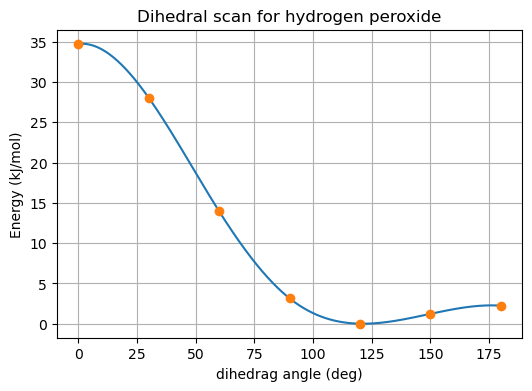

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

au2kJmol = 2625.50

npoints = len(opt_results["scan_energies"])

x = np.linspace(0, 180, npoints)
y = np.array(opt_results["scan_energies"])

y = (y - np.min(y)) * au2kJmol

cs = CubicSpline(x, y)
x_fine = np.linspace(x.min(), x.max(), 400)
y_fine = cs(x_fine)

plt.figure(figsize=(6, 4))
plt.plot(x_fine, y_fine, '-')
plt.plot(x, y, 'o')

plt.grid(True)

plt.title("Dihedral scan for hydrogen peroxide")
plt.xlabel('dihedrag angle (deg)')
plt.ylabel('Energy (kJ/mol)')

plt.show()

**Text file**

:::{code}
@jobs
task: optimize
@end

@method settings
xcfun: b3lyp
basis: def2-svp
@end

@optimize
scan dihedral 1 3 4 2 180 0 9
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

:::{figure} ../images/bithio-scan.gif
:width: 400px
:align: center

Figure: Relaxed scan of dihedral angle in the ground state, S$_0$.
:::